# LSTM(Uzun Kısa Süreli Bellek)

Geçmiş bilgilerin geleceğe entegre edilerek, gradyan kaybolması problemi le savaşan öz yinelemeli sinir ağıdır. Geçmişten yani long'tan hatırlar, yakından yani short'tan tahminler.

![lstm-mimari](lstm_mimari.png)

# LSTM ile Hisse Senedi Fiyatı Tahmini
1. İş problemi
2. Veriyi anlama
3. Veriyi hazırlama
4. Modelleme
5. Değerlendirme

## 2. Veriyi anlama

In [1]:
# Veriyi okuma ve işleme adımında kullanılacak olan kütüphaneler
import numpy as np
import pandas as pd
import datetime as df
import tensorflow as tf
import matplotlib.pyplot as plt

# Model değerlendirme ve veriyi scale edebilmemiz için kullanılacak olan kütüphaneler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Model için kullanılacak olan kütüphaneler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Uyarıları kapatmak için kullanılacak kütüphane
import warnings
warnings.filterwarnings("ignore")

# Tensorflow warning engelleme
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-05-02 16:07:08.623100: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.select_dtypes(include='number').quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)


In [4]:
check_df(df)

##################### Shape #####################
(2416, 7)
##################### Types #####################
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
##################### Head #####################
         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
##################### Tail #####################
            Date        Open        High         Low       Close   Adj Close  \
2411  2020-01-28  568.489990  576.809998  558.080017  566.900024  566.900024   
2412  2020-01-29  575

## 3. Veriyi hazırlama

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [7]:
tesla_df = df[["Date", "Close"]]

In [8]:
tesla_df.head()

,Date,Close
0,2010-06-29,23.889999
1,2010-06-30,23.830000
2,2010-07-01,21.959999
3,2010-07-02,19.200001
4,2010-07-06,16.110001


In [9]:
print("Minimum tarih: ", tesla_df["Date"].min())
print("Maximum tarih: ", tesla_df["Date"].max())

Minimum tarih:  2010-06-29 00:00:00
Maximum tarih:  2020-02-03 00:00:00


In [10]:
tesla_df.index = tesla_df["Date"]

In [11]:
tesla_df.drop("Date", axis = 1, inplace = True)

In [12]:
tesla_df

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001
...,...
2020-01-28,566.900024
2020-01-29,580.989990
2020-01-30,640.809998


In [13]:
result_df = tesla_df.copy()

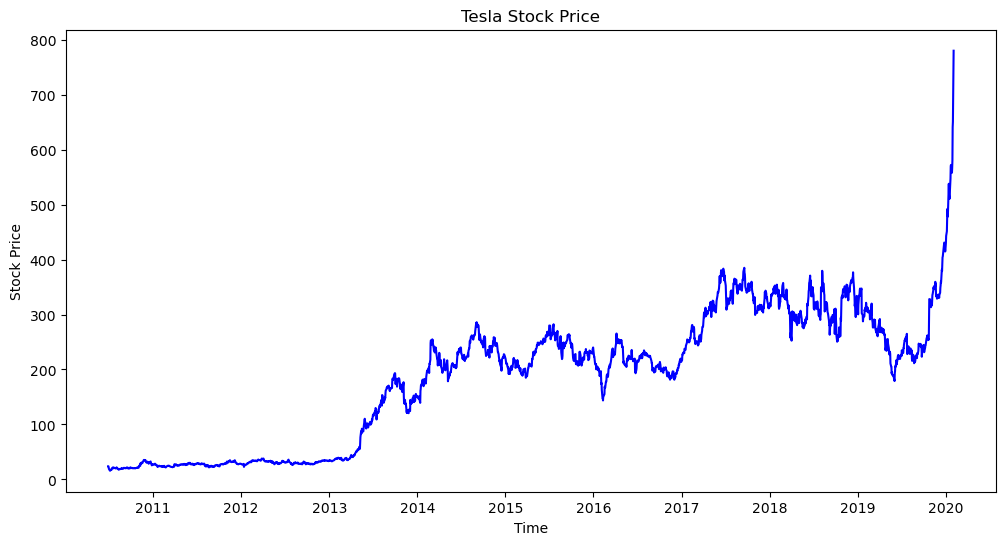

In [14]:
plt.figure(figsize= (12, 6))
plt.plot(tesla_df["Close"], color = "Blue")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Tesla Stock Price")
plt.show()

In [15]:
tesla_df = tesla_df.values

In [16]:
tesla_df

array([[ 23.889999],
       [ 23.83    ],
       [ 21.959999],
       ...,
       [640.809998],
       [650.570007],
       [780.      ]])

In [17]:
tesla_df = tesla_df.astype("float32")  #Sinir ağlarında bu format kullanılıyor

In [18]:
# Train test ayırımı yapalım
def split_data(dataframe, test_size):
    pos = int(round(len(dataframe) * (1 - test_size)))
    train = dataframe[:pos]
    test = dataframe[pos:]
    return train, test, pos

In [19]:
train, test, pos = split_data(tesla_df, 0.20)

In [20]:
print(train.shape, test.shape)

(1933, 1) (483, 1)


In [21]:
scaler_train = MinMaxScaler(feature_range= (0, 1))
train = scaler_train.fit_transform(train)
train[0:5]

array([[0.02191224],
       [0.02174973],
       [0.01668472],
       [0.0092091 ],
       [0.00083966]], dtype=float32)

In [22]:
scaler_test = MinMaxScaler(feature_range= (0 ,1))
test = scaler_test.fit_transform(test)
test[0:5]

array([[0.25685903],
       [0.24829045],
       [0.25511202],
       [0.24978784],
       [0.2465767 ]], dtype=float32)

In [23]:
def create_features(data, lookback):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        Y.append(data[i, 0])

    return np.array(X), np.array(Y)

In [24]:
lookback = 20 # 20 gün önce

In [25]:
X_train, y_train = create_features(train, lookback)
X_test, y_test = create_features(test, lookback)

In [26]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1913, 20) (1913,) (463, 20) (463,)


In [27]:
X_train[0:5]

array([[0.02191224, 0.02174973, 0.01668472, 0.0092091 , 0.00083966,
        0.        , 0.00449621, 0.00433369, 0.0033857 , 0.00633803,
        0.01094258, 0.011078  , 0.01310942, 0.0165493 , 0.01218851,
        0.01197183, 0.01408451, 0.01486999, 0.01394908, 0.01286566],
       [0.02174973, 0.01668472, 0.0092091 , 0.00083966, 0.        ,
        0.00449621, 0.00433369, 0.0033857 , 0.00633803, 0.01094258,
        0.011078  , 0.01310942, 0.0165493 , 0.01218851, 0.01197183,
        0.01408451, 0.01486999, 0.01394908, 0.01286566, 0.01332611],
       [0.01668472, 0.0092091 , 0.00083966, 0.        , 0.00449621,
        0.00433369, 0.0033857 , 0.00633803, 0.01094258, 0.011078  ,
        0.01310942, 0.0165493 , 0.01218851, 0.01197183, 0.01408451,
        0.01486999, 0.01394908, 0.01286566, 0.01332611, 0.01232395],
       [0.0092091 , 0.00083966, 0.        , 0.00449621, 0.00433369,
        0.0033857 , 0.00633803, 0.01094258, 0.011078  , 0.01310942,
        0.0165493 , 0.01218851, 0.01197183, 0

In [28]:
y_train[0:5]

array([0.01332611, 0.01232395, 0.01121344, 0.01386782, 0.01665764],
      dtype=float32)

In [29]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))      #LSTM girdi olarak veriyi 3 boyutlu istiyor
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1913, 1, 20) (1913, 1) (463, 1, 20) (463, 1)


## 4. Modelleme

In [30]:
# Modelin dış iskelertini(mimarisini) oluşturalım
model = Sequential()

model.add(LSTM(units= 50, activation= "relu", input_shape = (X_train.shape[1], lookback)))
model.add(Dropout(0.2))
model.add(Dense(1))

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        14,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,251 (55.67 KB)

 Trainable params: 14,251 (55.67 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss = "mean_squared_error", optimizer = "adam")

In [33]:
callbacks = [EarlyStopping(monitor = "val_loss", patience = 3, verbose =1, mode = "min"),
            ModelCheckpoint(filepath= "my model.keras", monitor = "val_loss", mode = "min", save_best_only= True,
                           save_weights_only= False, verbose = 1)]

In [34]:
history = model.fit(x = X_train, y = y_train, epochs = 100, batch_size = 20, validation_data= (X_test, y_test),
                     callbacks= callbacks, shuffle= False)

Epoch 1/100
83/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047   
Epoch 1: val_loss improved from inf to 0.00453, saving model to my model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0054 - val_loss: 0.0045
Epoch 2/100
75/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053
Epoch 2: val_loss improved from 0.00453 to 0.00397, saving model to my model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 - val_loss: 0.0040
Epoch 3/100
80/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041
Epoch 3: val_loss improved from 0.00397 to 0.00356, saving model to my model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 4/100
80/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031
Epoch 4: val_loss improved from 0.00356 to 0.00328, saving model to my model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - val_loss: 0.0033
Epoch 5/100
79/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024
Epoch 5: val_loss improved from 0.00328 to 0.00

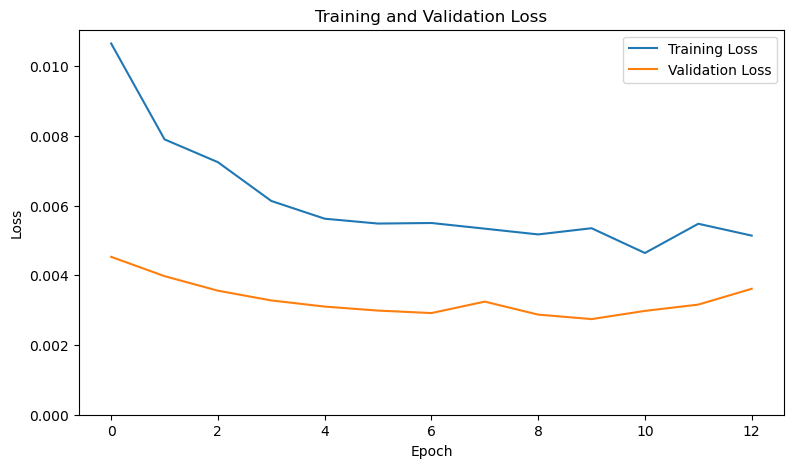

In [35]:
plt.figure(figsize= (20, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.legend(loc = "upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim([0, max(plt.ylim())])
plt.title("Training and Validation Loss")
plt.show()

## 5. Değerlendirme

In [36]:
loss = model.evaluate(X_test, y_test, batch_size=1)
print("Train loss:", (100 * loss))

463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037
Train loss: 0.36115911789238453


In [37]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [38]:
train_predict = scaler_train.inverse_transform(train_predict)
test_predict = scaler_test.inverse_transform(test_predict)

In [39]:
y_train = scaler_train.inverse_transform(y_train)
y_test = scaler_test.inverse_transform(y_test)

In [40]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

In [41]:
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 17.425621032714844
Test RMSE: 36.11981964111328


In [42]:
train_prediction_df = result_df[lookback:pos]
train_prediction_df["Prediction"] = train_predict
train_prediction_df.head(5)

,Close,Prediction
Date,,
2010-07-28,20.719999,39.006126
2010-07-29,20.350000,39.006126
2010-07-30,19.940001,39.006126
2010-08-02,20.920000,39.006126
2010-08-03,21.950001,39.006126


In [44]:
test_prediction_df = result_df[pos + lookback:]
test_prediction_df["Prediction"] = test_predict
test_prediction_df.head(5)

,Close,Prediction
Date,,
2018-04-03,267.529999,332.260162
2018-04-04,286.940002,329.148132
2018-04-05,305.720001,326.241516
2018-04-06,299.299988,327.517639
2018-04-09,289.660004,328.931763


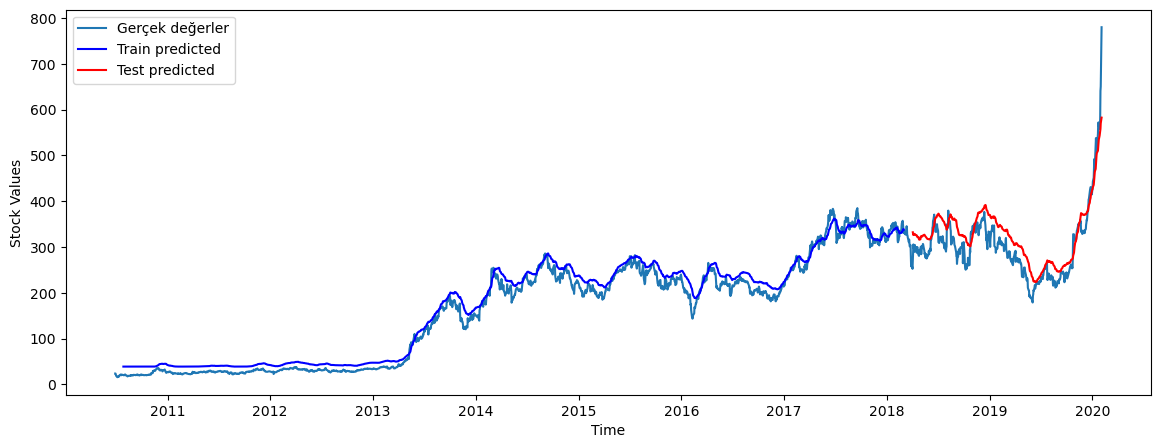

In [45]:
# Train ve test tahminlerini görselleştirelim
plt.figure(figsize= (14, 5))
plt.plot(result_df, label = "Gerçek değerler")
plt.plot(train_prediction_df["Prediction"], color = "blue",label = "Train predicted")
plt.plot(test_prediction_df["Prediction"], color = "red",label = "Test predicted")
plt.xlabel("Time")
plt.ylabel("Stock Values")
plt.legend()
plt.show()

32 dolarlık bir sapma ile tahmin yapan bir model geliştirmiş olduk.